# Mall Customer Segmentation Analysis
**Analyst:** Data Team  |  **Date:** 2026-07-25  |  **Report To:** Senior Data Analyst / BI Lead

**Objective:** Explore the mall customers dataset to understand demographics, spending behaviour, surface high-value segments, and provide actionable recommendations via K-Means clustering.


## 0. Dependencies

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
from matplotlib.colors import LinearSegmentedColormap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

%matplotlib inline

# ── Red & White Palette ────────────────────────────────────────────────
DARK    = "#7B241C"   # deep red  — strong emphasis / Male
CRIMSON = "#C0392B"   # brand red — primary
ROSE    = "#E74C3C"   # medium red
BLUSH   = "#F1948A"   # light red — Female / secondary
PETAL   = "#FADBD8"   # near-white red — backgrounds / subtle fills

RED5    = [DARK, CRIMSON, ROSE, BLUSH, PETAL]   # 5-cluster palette
RED4    = [DARK, CRIMSON, ROSE, BLUSH]           # 4-group palette
RED3    = [DARK, CRIMSON, BLUSH]                 # 3-tier palette

# diverging colormap: PETAL → white → DARK  (for correlation heatmap)
RED_DIV = LinearSegmentedColormap.from_list("red_div", [PETAL, "white", DARK])

sns.set_theme(style="white")
plt.rcParams.update({
    "figure.dpi"         : 120,
    "figure.facecolor"   : "white",
    "axes.facecolor"     : "white",
    "axes.edgecolor"     : CRIMSON,
    "axes.labelcolor"    : DARK,
    "xtick.color"        : DARK,
    "ytick.color"        : DARK,
    "text.color"         : "#2C2C2C",
    "axes.titlecolor"    : DARK,
    "axes.spines.top"    : False,
    "axes.spines.right"  : False,
    "grid.color"         : PETAL,
    "grid.linewidth"     : 0.6,
    "legend.framealpha"  : 0.9,
    "legend.edgecolor"   : PETAL,
})

def style_table(df):
    return (df.style
        .set_table_styles([
            {"selector": "thead th", "props": [
                ("background-color", CRIMSON),
                ("color", "white"),
                ("font-weight", "bold"),
                ("border", f"2px solid {DARK}"),
                ("padding", "8px 14px"),
                ("text-align", "center"),
            ]},
            {"selector": "th.row_heading", "props": [
                ("background-color", ROSE),
                ("color", "white"),
                ("font-weight", "bold"),
                ("border", f"1px solid {CRIMSON}"),
                ("padding", "6px 12px"),
            ]},
            {"selector": "th.index_name", "props": [
                ("background-color", DARK),
                ("color", "white"),
                ("font-weight", "bold"),
            ]},
            {"selector": "tbody tr:nth-child(even) td", "props": [
                ("background-color", PETAL),
            ]},
            {"selector": "tbody tr:nth-child(odd) td", "props": [
                ("background-color", "white"),
            ]},
            {"selector": "tbody td", "props": [
                ("border", f"1px solid {PETAL}"),
                ("padding", "6px 14px"),
                ("color", DARK),
                ("text-align", "center"),
            ]},
            {"selector": "tbody tr:hover td", "props": [
                ("background-color", BLUSH),
                ("color", "white"),
            ]},
            {"selector": "table", "props": [
                ("border-collapse", "collapse"),
                ("border", f"2px solid {CRIMSON}"),
                ("font-family", "sans-serif"),
                ("font-size", "13px"),
            ]},
        ])
    )

HERE      = Path(".")
DATA_PATH = HERE / "Mall_Customers.csv"
print("Theme loaded — Red & White (charts + tables)")

Theme loaded — Red & White (charts + tables)


## 1. Load & Validate

In [2]:
df = pd.read_csv(DATA_PATH)
df.columns = ["CustomerID", "Gender", "Age", "Income_k", "SpendingScore"]

print(f"Rows            : {len(df)}")
print(f"Columns         : {df.shape[1]}")
print(f"Missing values  : {df.isnull().sum().sum()}")
print(f"Duplicate rows  : {df.duplicated().sum()}")
print(f"CustomerID range: {df.CustomerID.min()} – {df.CustomerID.max()}")
print()
print(df.dtypes.to_string())

Rows            : 200
Columns         : 5
Missing values  : 0
Duplicate rows  : 0
CustomerID range: 1 – 200

CustomerID        int64
Gender           object
Age               int64
Income_k          int64
SpendingScore     int64


In [3]:
print("Outlier check (IQR method):")
for col in ["Age", "Income_k", "SpendingScore"]:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    n_out = ((df[col] < q1 - 1.5 * iqr) | (df[col] > q3 + 1.5 * iqr)).sum()
    print(f"  {col:<15}: {n_out} outlier(s)  [IQR range: {q1:.0f}–{q3:.0f}]")

Outlier check (IQR method):
  Age            : 0 outlier(s)  [IQR range: 29–49]
  Income_k       : 2 outlier(s)  [IQR range: 42–78]
  SpendingScore  : 0 outlier(s)  [IQR range: 35–73]


## 2. Descriptive Statistics

In [4]:
style_table(df[["Age", "Income_k", "SpendingScore"]].describe().round(2))

,Age,Income_k,SpendingScore
count,200.000000,200.000000,200.000000
mean,38.850000,60.560000,50.200000
std,13.970000,26.260000,25.820000
min,18.000000,15.000000,1.000000
25%,28.750000,41.500000,34.750000
50%,36.000000,61.500000,50.000000
75%,49.000000,78.000000,73.000000
max,70.000000,137.000000,99.000000


In [5]:
gender_counts = df["Gender"].value_counts()
gender_pct    = (gender_counts / len(df) * 100).round(1)
print("Gender split:")
for g in gender_counts.index:
    print(f"  {g}: {gender_counts[g]} ({gender_pct[g]}%)")

Gender split:
  Female: 112 (56.0%)
  Male: 88 (44.0%)


In [6]:
df["SpendTier"] = pd.cut(
    df["SpendingScore"],
    bins=[0, 33, 66, 100],
    labels=["Low (1–33)", "Medium (34–66)", "High (67–100)"],
)
tier_counts = df["SpendTier"].value_counts().sort_index()
print("Spending tier breakdown:")
for tier, cnt in tier_counts.items():
    print(f"  {tier:<20}: {cnt} ({cnt/len(df)*100:.1f}%)")

Spending tier breakdown:
  Low (1–33)          : 49 (24.5%)
  Medium (34–66)      : 94 (47.0%)
  High (67–100)       : 57 (28.5%)


## 3. Exploratory Analysis

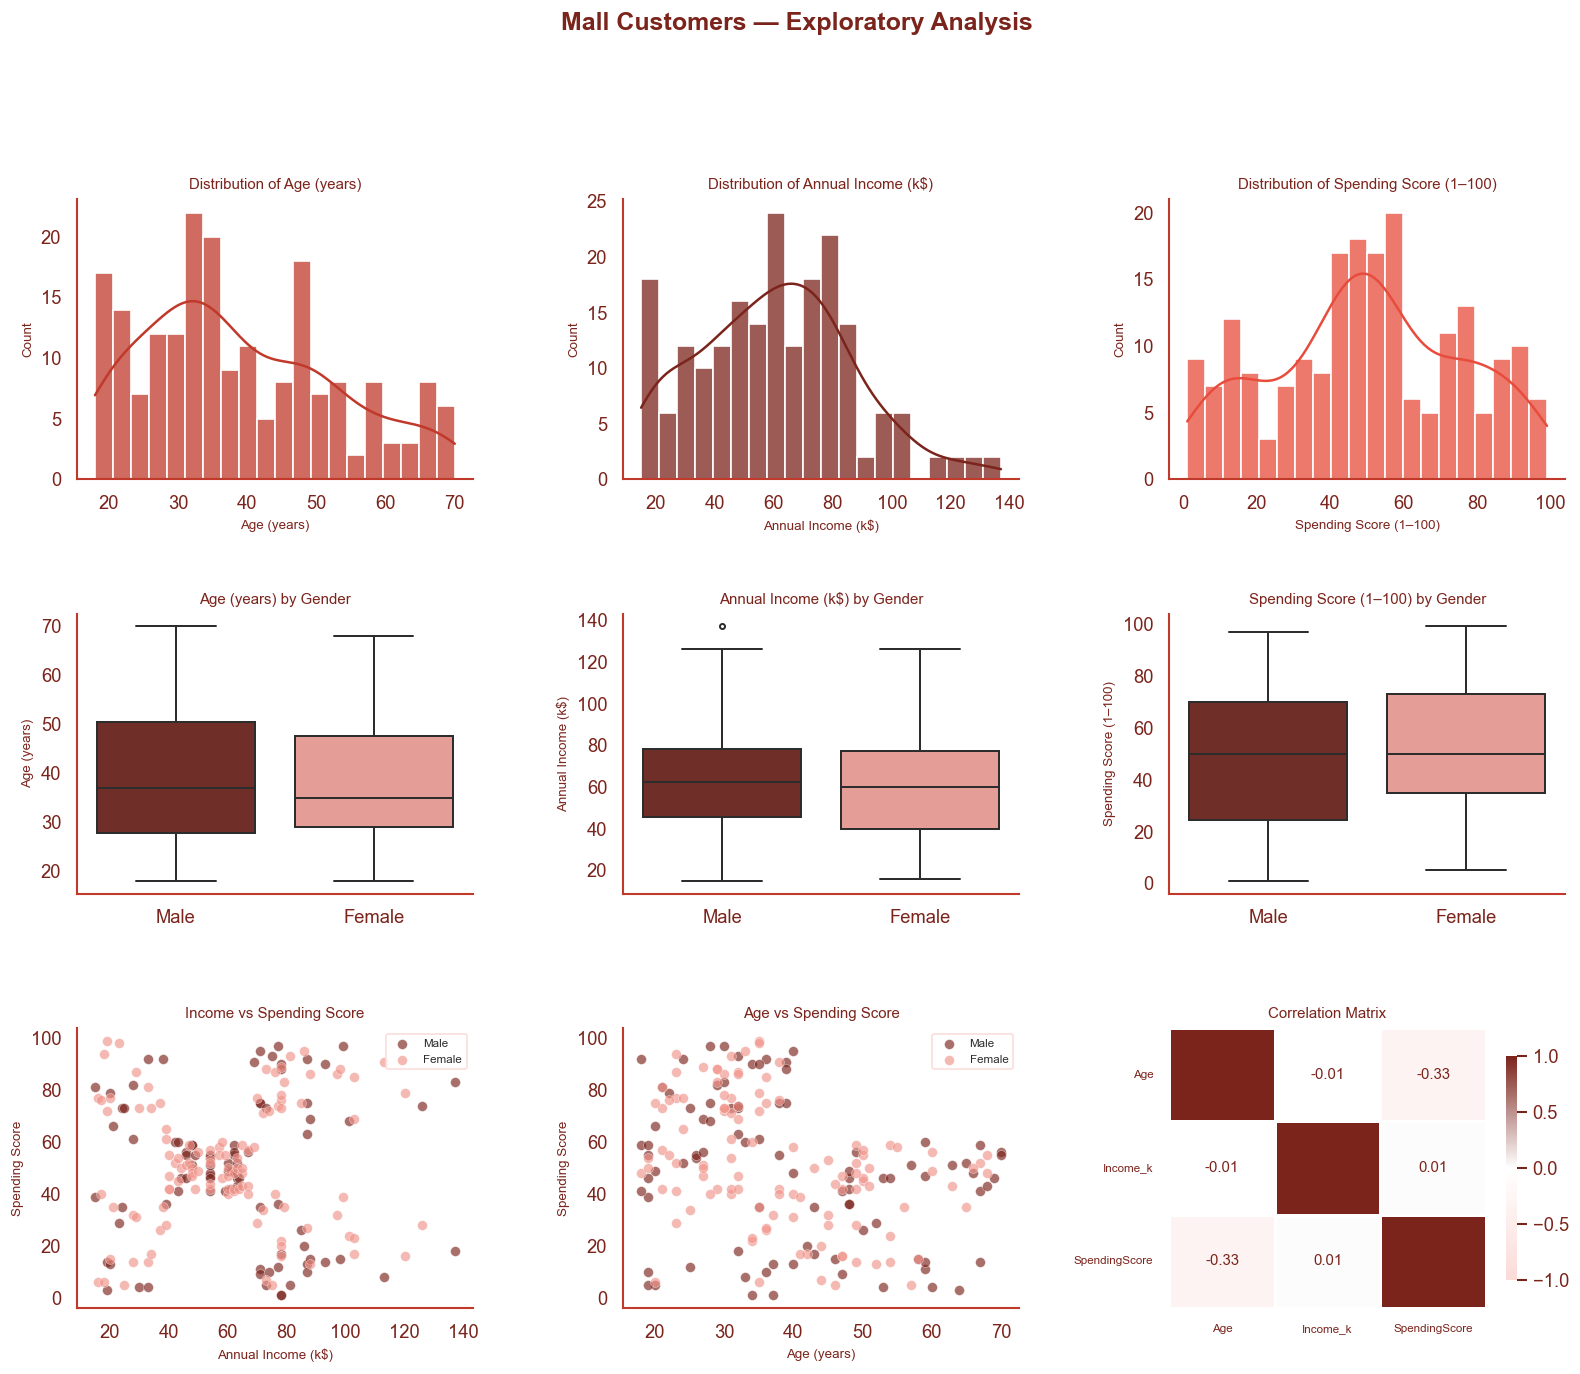

In [7]:
features = ["Age", "Income_k", "SpendingScore"]
flabels  = ["Age (years)", "Annual Income (k$)", "Spending Score (1–100)"]
hist_colors = [CRIMSON, DARK, ROSE]

fig = plt.figure(figsize=(16, 12))
fig.suptitle("Mall Customers — Exploratory Analysis",
             fontsize=15, fontweight="bold", color=DARK, y=1.01)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.48, wspace=0.38)

# Row 0: Histograms
for i, (col, lbl) in enumerate(zip(features, flabels)):
    ax = fig.add_subplot(gs[0, i])
    sns.histplot(df[col], bins=20, kde=True, ax=ax,
                 color=hist_colors[i], alpha=0.75,
                 line_kws={"color": DARK, "linewidth": 1.5})
    ax.set_title(f"Distribution of {lbl}", fontsize=9, color=DARK)
    ax.set_xlabel(lbl, fontsize=8); ax.set_ylabel("Count", fontsize=8)

# Row 1: Boxplots by gender
for i, (col, lbl) in enumerate(zip(features, flabels)):
    ax = fig.add_subplot(gs[1, i])
    sns.boxplot(data=df, x="Gender", y=col, ax=ax,
                palette={"Male": DARK, "Female": BLUSH},
                linewidth=1.2, flierprops={"marker": "o", "color": CRIMSON, "markersize": 3})
    ax.set_title(f"{lbl} by Gender", fontsize=9, color=DARK)
    ax.set_xlabel(""); ax.set_ylabel(lbl, fontsize=8)

# Row 2 left: Income vs Spending scatter
ax = fig.add_subplot(gs[2, 0])
for g, c in zip(["Male", "Female"], [DARK, BLUSH]):
    sub = df[df.Gender == g]
    ax.scatter(sub.Income_k, sub.SpendingScore, alpha=0.65, s=35, color=c, label=g, edgecolors="white", linewidths=0.3)
ax.set_title("Income vs Spending Score", fontsize=9, color=DARK)
ax.set_xlabel("Annual Income (k$)", fontsize=8)
ax.set_ylabel("Spending Score", fontsize=8)
ax.legend(fontsize=7)

# Row 2 middle: Age vs Spending scatter
ax = fig.add_subplot(gs[2, 1])
for g, c in zip(["Male", "Female"], [DARK, BLUSH]):
    sub = df[df.Gender == g]
    ax.scatter(sub.Age, sub.SpendingScore, alpha=0.65, s=35, color=c, label=g, edgecolors="white", linewidths=0.3)
ax.set_title("Age vs Spending Score", fontsize=9, color=DARK)
ax.set_xlabel("Age (years)", fontsize=8)
ax.set_ylabel("Spending Score", fontsize=8)
ax.legend(fontsize=7)

# Row 2 right: Correlation heatmap
ax = fig.add_subplot(gs[2, 2])
corr = df[features].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap=RED_DIV, vmin=-1, vmax=1,
            ax=ax, linewidths=0.8, linecolor="white",
            annot_kws={"size": 9, "color": DARK},
            cbar_kws={"shrink": 0.8})
ax.set_title("Correlation Matrix", fontsize=9, color=DARK)
ax.tick_params(labelsize=7, colors=DARK)

plt.tight_layout()
plt.show()

### Correlation Summary

In [8]:
print("Pearson correlations:")
for pair in [("Age", "Income_k"), ("Age", "SpendingScore"), ("Income_k", "SpendingScore")]:
    r = df[list(pair)].corr().iloc[0, 1]
    print(f"  {pair[0]} vs {pair[1]}: r = {r:.3f}")

Pearson correlations:
  Age vs Income_k: r = -0.012
  Age vs SpendingScore: r = -0.327
  Income_k vs SpendingScore: r = 0.010


## 4. Age Group Analysis

In [9]:
age_bins   = [17, 25, 35, 50, 70]
age_labels = ["18–25", "26–35", "36–50", "51–70"]
df["AgeGroup"] = pd.cut(df["Age"], bins=age_bins, labels=age_labels)

age_profile = (
    df.groupby("AgeGroup", observed=True)
    .agg(
        Count=("CustomerID", "count"),
        Avg_Income=("Income_k", "mean"),
        Avg_Spending=("SpendingScore", "mean"),
        Pct_Female=("Gender", lambda x: round((x == "Female").mean() * 100, 1)),
    )
    .round(1)
)
style_table(age_profile)

,Count,Avg_Income,Avg_Spending,Pct_Female
AgeGroup,,,,
18–25,38,45.700000,54.900000,52.600000
26–35,60,68.200000,64.400000,61.700000
36–50,62,66.700000,41.700000,59.700000
51–70,40,53.800000,37.500000,45.000000


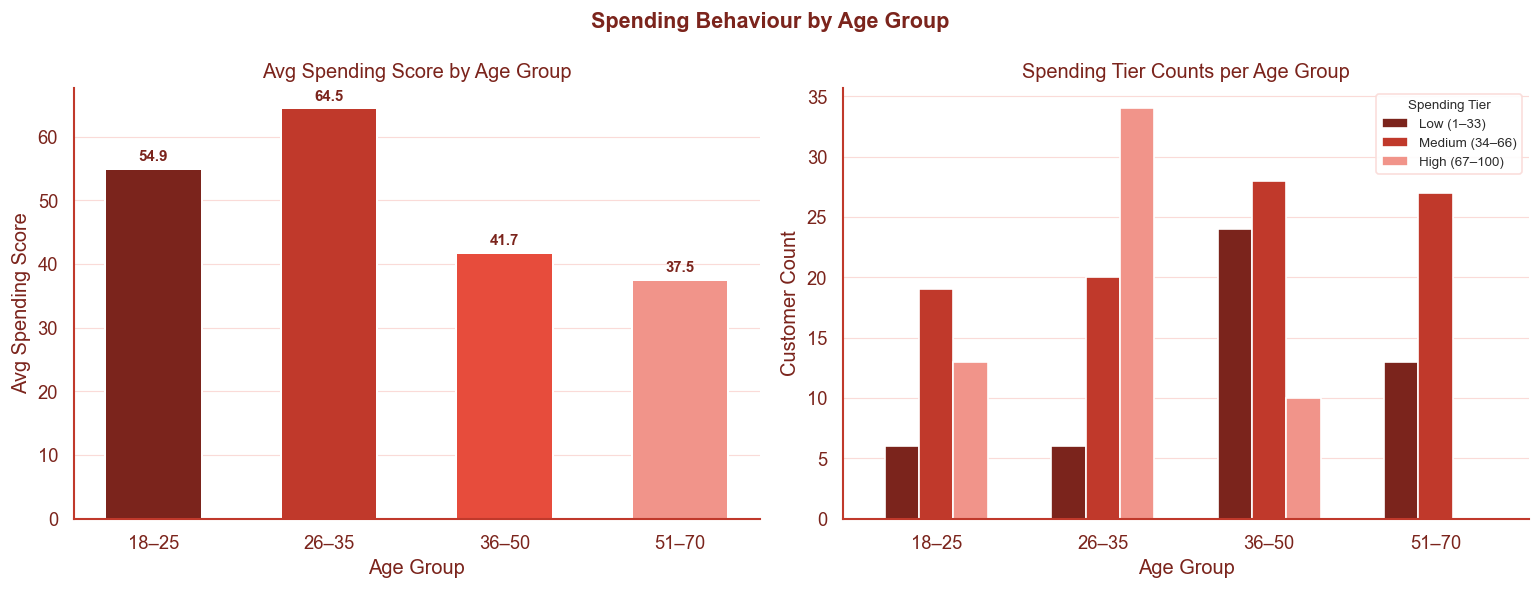

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Spending Behaviour by Age Group", fontsize=13, fontweight="bold", color=DARK)

# Left: avg spending score per age group
ax = axes[0]
avg_spend = df.groupby("AgeGroup", observed=True)["SpendingScore"].mean().reindex(age_labels)
bars = ax.bar(age_labels, avg_spend, color=RED4, edgecolor="white", width=0.55, linewidth=1.2)
ax.set_title("Avg Spending Score by Age Group", color=DARK)
ax.set_xlabel("Age Group"); ax.set_ylabel("Avg Spending Score")
ax.yaxis.grid(True, color=PETAL, linewidth=0.7)
ax.set_axisbelow(True)
for bar, val in zip(bars, avg_spend):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            f"{val:.1f}", ha="center", va="bottom", fontsize=9, color=DARK, fontweight="bold")

# Right: spending tier stacked bar
ax = axes[1]
tier_age = (
    df.groupby(["AgeGroup", "SpendTier"], observed=True)
    .size()
    .unstack(fill_value=0)
)
tier_age.plot(kind="bar", ax=ax, color=RED3, edgecolor="white", width=0.62, linewidth=1.0)
ax.set_title("Spending Tier Counts per Age Group", color=DARK)
ax.set_xlabel("Age Group"); ax.set_ylabel("Customer Count")
ax.set_xticklabels(age_labels, rotation=0)
ax.yaxis.grid(True, color=PETAL, linewidth=0.7)
ax.set_axisbelow(True)
ax.legend(title="Spending Tier", fontsize=8, title_fontsize=8)

plt.tight_layout()
plt.show()

## 5. K-Means Clustering — Optimal k

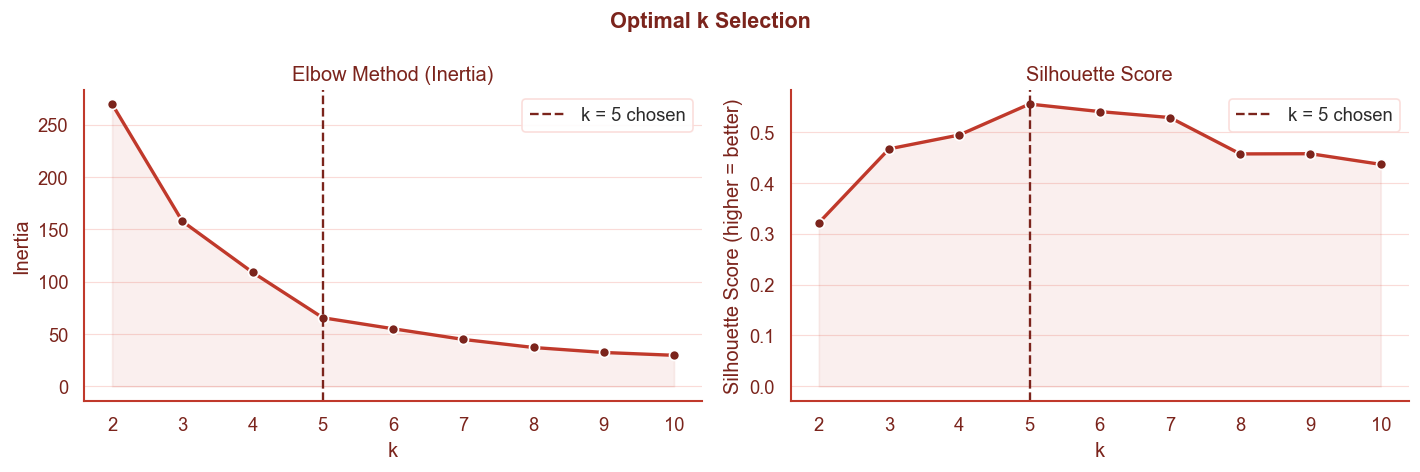

Best k by silhouette : 5  (score = 0.555)
Business choice      : 5  (interpretable retail segments)


In [11]:
X        = df[["Income_k", "SpendingScore"]].values
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertias, silhouettes = [], []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, init="k-means++", n_init=20, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Optimal k Selection", fontsize=13, fontweight="bold", color=DARK)

axes[0].plot(list(K_range), inertias, "o-", color=CRIMSON, linewidth=2, markersize=6,
             markerfacecolor=DARK, markeredgecolor="white")
axes[0].fill_between(list(K_range), inertias, alpha=0.08, color=CRIMSON)
axes[0].set_title("Elbow Method (Inertia)", color=DARK)
axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia")
axes[0].axvline(x=5, color=DARK, linestyle="--", linewidth=1.4, label="k = 5 chosen")
axes[0].yaxis.grid(True, color=PETAL, linewidth=0.7); axes[0].set_axisbelow(True)
axes[0].legend()

axes[1].plot(list(K_range), silhouettes, "o-", color=CRIMSON, linewidth=2, markersize=6,
             markerfacecolor=DARK, markeredgecolor="white")
axes[1].fill_between(list(K_range), silhouettes, alpha=0.08, color=CRIMSON)
axes[1].set_title("Silhouette Score", color=DARK)
axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette Score (higher = better)")
axes[1].axvline(x=5, color=DARK, linestyle="--", linewidth=1.4, label="k = 5 chosen")
axes[1].yaxis.grid(True, color=PETAL, linewidth=0.7); axes[1].set_axisbelow(True)
axes[1].legend()

plt.tight_layout()
plt.show()

best_k = list(K_range)[np.argmax(silhouettes)]
print(f"Best k by silhouette : {best_k}  (score = {max(silhouettes):.3f})")
print(f"Business choice      : 5  (interpretable retail segments)")

## 6. Fit Final Model (k = 5)

In [12]:
K_FINAL  = 5
km_final = KMeans(n_clusters=K_FINAL, init="k-means++", n_init=50, random_state=42)
df["Cluster"] = km_final.fit_predict(X_scaled)

profile = (
    df.groupby("Cluster")
    .agg(
        Count=("CustomerID", "count"),
        Avg_Age=("Age", "mean"),
        Avg_Income=("Income_k", "mean"),
        Avg_Spending=("SpendingScore", "mean"),
        Pct_Female=("Gender", lambda x: round((x == "Female").mean() * 100, 1)),
    )
    .round(1)
)
style_table(profile)

,Count,Avg_Age,Avg_Income,Avg_Spending,Pct_Female
Cluster,,,,,
0,81,42.700000,55.300000,49.500000,59.300000
1,39,32.700000,86.500000,82.100000,53.800000
2,22,25.300000,25.700000,79.400000,59.100000
3,35,41.100000,88.200000,17.100000,45.700000
4,23,45.200000,26.300000,20.900000,60.900000


## 7. Segment Labelling (Data-Driven)

In [13]:
centroids_orig = scaler.inverse_transform(km_final.cluster_centers_)
grand_centroid = centroids_orig.mean(axis=0)
distances      = np.linalg.norm(centroids_orig - grand_centroid, axis=1)
middle_idx     = int(np.argmin(distances))

inc_mid = df["Income_k"].median()
sp_mid  = df["SpendingScore"].median()

labels_map = {}
for idx, (inc, sp) in enumerate(centroids_orig):
    if idx == middle_idx:
        labels_map[idx] = "Middle Income, Average Spenders"
    elif inc > inc_mid and sp > sp_mid:
        labels_map[idx] = "High Income, High Spenders  ★ TARGET"
    elif inc > inc_mid and sp <= sp_mid:
        labels_map[idx] = "High Income, Low Spenders   ⚠ RE-ENGAGE"
    elif inc <= inc_mid and sp > sp_mid:
        labels_map[idx] = "Low Income, High Spenders"
    else:
        labels_map[idx] = "Low Income, Low Spenders"

df["Segment"] = df["Cluster"].map(labels_map)

print(f"Centre cluster  : Cluster {middle_idx}")
print(f"Income median   : ${inc_mid:.0f}k")
print(f"Spending median : {sp_mid:.0f}")
print()
for k, v in sorted(labels_map.items()):
    print(f"  Cluster {k}: {v}")

Centre cluster  : Cluster 0
Income median   : $62k
Spending median : 50

  Cluster 0: Middle Income, Average Spenders
  Cluster 1: High Income, High Spenders  ★ TARGET
  Cluster 2: Low Income, High Spenders
  Cluster 3: High Income, Low Spenders   ⚠ RE-ENGAGE
  Cluster 4: Low Income, Low Spenders


## 8. Cluster Visualisation

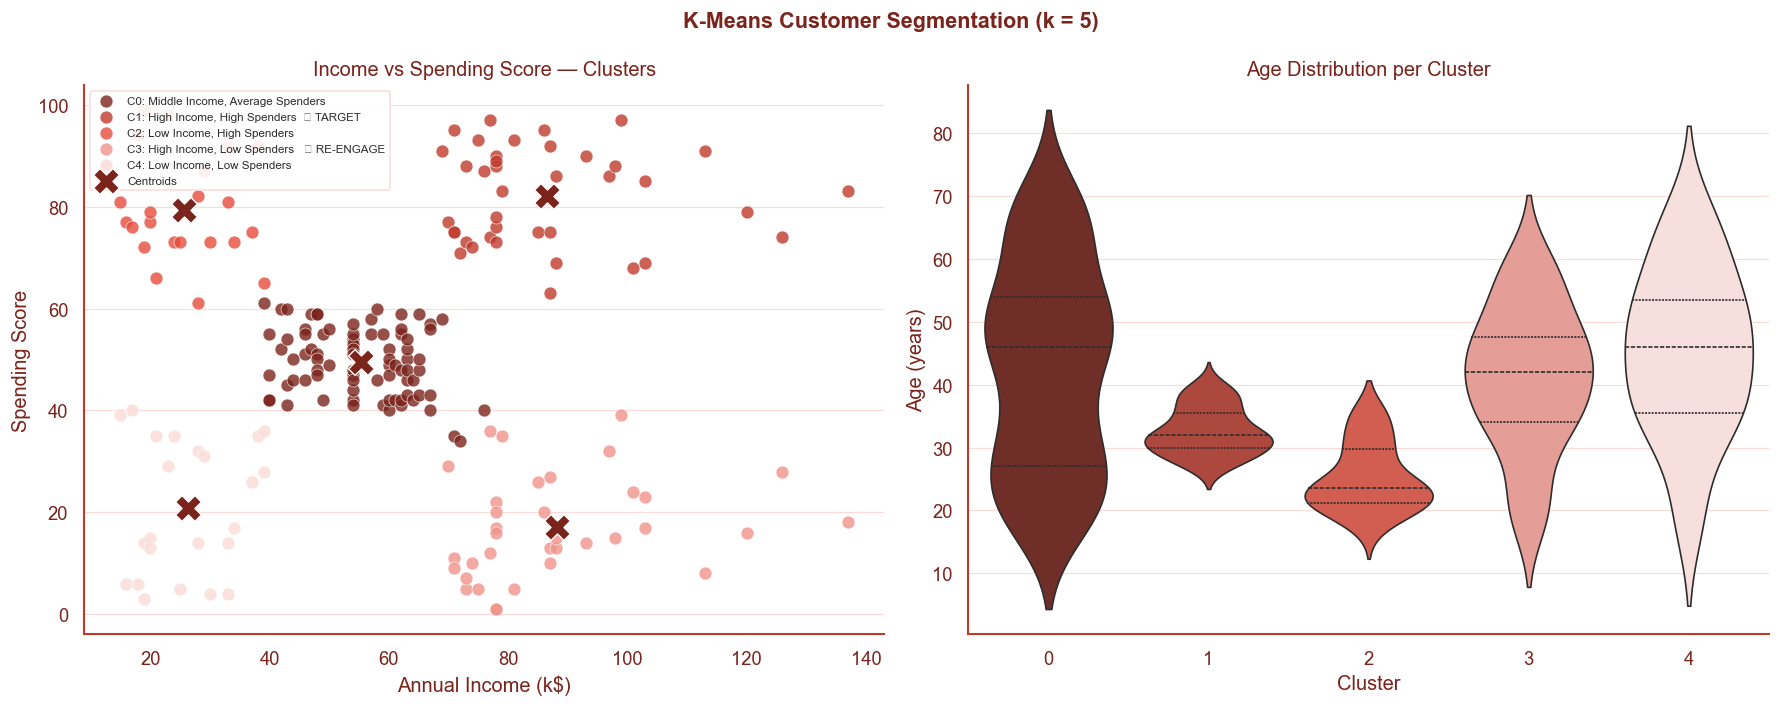

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("K-Means Customer Segmentation (k = 5)",
             fontsize=13, fontweight="bold", color=DARK)

# Left: scatter coloured by cluster
ax = axes[0]
for c in range(K_FINAL):
    sub = df[df.Cluster == c]
    ax.scatter(sub.Income_k, sub.SpendingScore,
               s=60, alpha=0.80, color=RED5[c],
               edgecolors="white", linewidths=0.4,
               label=f"C{c}: {labels_map[c]}")
cx, cy = centroids_orig[:, 0], centroids_orig[:, 1]
ax.scatter(cx, cy, s=240, c=DARK, marker="X", zorder=6,
           edgecolors="white", linewidths=0.8, label="Centroids")
ax.set_title("Income vs Spending Score — Clusters", color=DARK)
ax.set_xlabel("Annual Income (k$)"); ax.set_ylabel("Spending Score")
ax.yaxis.grid(True, color=PETAL, linewidth=0.7); ax.set_axisbelow(True)
ax.legend(fontsize=7, loc="upper left")

# Right: age violin per cluster
ax = axes[1]
sns.violinplot(data=df, x="Cluster", y="Age",
               palette=RED5, ax=ax, inner="quartile",
               linewidth=1.0)
ax.set_title("Age Distribution per Cluster", color=DARK)
ax.set_xlabel("Cluster"); ax.set_ylabel("Age (years)")
ax.yaxis.grid(True, color=PETAL, linewidth=0.7); ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

## 9. Gender × Cluster

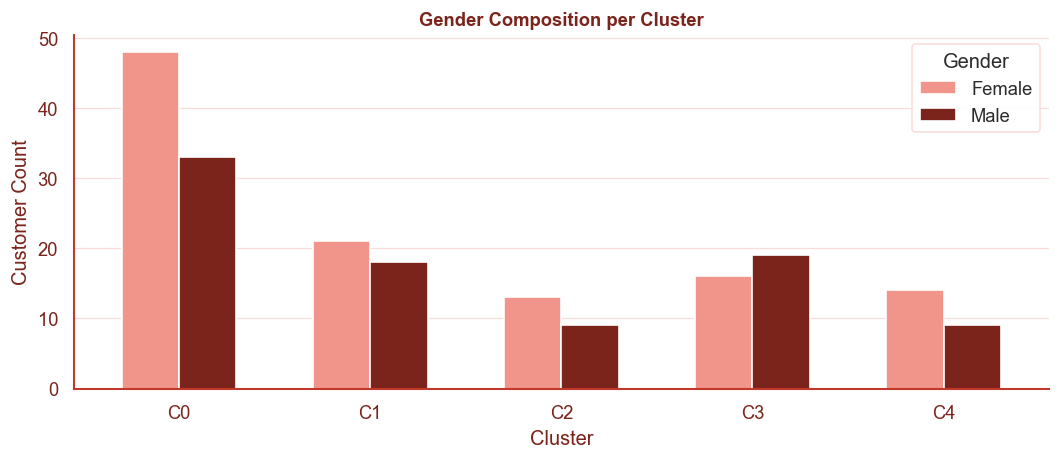

In [15]:
fig, ax = plt.subplots(figsize=(9, 4))

gender_cluster = (
    df.groupby(["Cluster", "Gender"])
    .size()
    .unstack(fill_value=0)
)
gender_cluster[["Female", "Male"]].plot(
    kind="bar", ax=ax,
    color=[BLUSH, DARK],
    edgecolor="white", width=0.6, linewidth=1.0
)
ax.set_title("Gender Composition per Cluster",
             fontsize=11, fontweight="bold", color=DARK)
ax.set_xlabel("Cluster"); ax.set_ylabel("Customer Count")
ax.set_xticklabels([f"C{i}" for i in range(K_FINAL)], rotation=0)
ax.yaxis.grid(True, color=PETAL, linewidth=0.7); ax.set_axisbelow(True)
ax.legend(title="Gender", labels=["Female", "Male"])

plt.tight_layout()
plt.show()

## 10. Executive Summary

In [16]:
sil = silhouette_score(X_scaled, df["Cluster"])
print(f"Model Quality — Silhouette Score: {sil:.3f}  (0.5+ = reasonable structure)")
print()

summary = (
    df.groupby("Segment")
    .agg(
        n=("CustomerID", "count"),
        Avg_Income=("Income_k", "mean"),
        Avg_Spending=("SpendingScore", "mean"),
        Avg_Age=("Age", "mean"),
        Pct_Female=("Gender", lambda x: round((x == "Female").mean() * 100, 1)),
    )
    .sort_values("Avg_Income", ascending=False)
    .round(1)
)
style_table(summary)

Model Quality — Silhouette Score: 0.555  (0.5+ = reasonable structure)



,n,Avg_Income,Avg_Spending,Avg_Age,Pct_Female
Segment,,,,,
"High Income, Low Spenders ⚠ RE-ENGAGE",35,88.200000,17.100000,41.100000,45.700000
"High Income, High Spenders ★ TARGET",39,86.500000,82.100000,32.700000,53.800000
"Middle Income, Average Spenders",81,55.300000,49.500000,42.700000,59.300000
"Low Income, Low Spenders",23,26.300000,20.900000,45.200000,60.900000
"Low Income, High Spenders",22,25.700000,79.400000,25.300000,59.100000


### Key Insights

| # | Segment | n | Action |
|---|---------|---|--------|
| 1 | **High Income, High Spenders ★** | 39 | Priority loyalty & premium campaigns |
| 2 | **High Income, Low Spenders ⚠** | 35 | Re-engagement — find the friction |
| 3 | Low Income, High Spenders | 22 | BNPL / flash sales / social campaigns |
| 4 | Low Income, Low Spenders | 23 | Footfall value only (food court, events) |
| 5 | Middle Income, Average Spenders | 81 | Largest group — upsell via tier membership |

### Age Group Findings
- **18–25**: Highest avg spending (~55). Small but high-intent cohort.
- **26–35**: Highest income + second-highest spending. Best ROI segment.
- **36–50**: Spending drops sharply (~42). Budget-conscious working age.
- **51–70**: Lowest engagement (~38). Not the primary CRM target.
- → **Marketing cutoff for youth campaigns: ≤35**

### Recommended Next Steps
- **A.** Enrich with transaction-level data to validate segments.
- **B.** A/B test targeted offers on Segments 1 and 3 for Q3 2026.
- **C.** Re-run clustering quarterly — segment membership drifts.
- **D.** Explore 3-feature clustering (Age + Income + SpendingScore).
- **E.** Deep-dive 26–35 age group — highest-value overlap, compounding ROI.
